# Agents Grading Agents: a Gold Medal on MLE-bench
### Spaceship Titanic, solved end-to-end by an autonomous agent — no human in the loop

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin)*

*Level: intermediate (GBDTs + stacking). Runs on a Kaggle CPU instance, no internet, full Run-All in a few minutes.*

A heads-up on what this really is. It's published on Spaceship Titanic, and it *does* contain a complete, reproducible solution — but the competition we actually entered is a different one. Berkeley's [AgentX–AgentBeats](https://rdi.berkeley.edu/agentx-agentbeats) is a competition in *building AI agents*, and its defining twist is that the benchmarks are themselves agents: instead of a fixed scorer, a **green** evaluator agent sets the task and grades the work, while your **purple** agent has to solve it. On the **MLE-bench** track that means the green agent hands a real Kaggle competition to your purple agent over the [A2A protocol](https://github.com/a2aproject/A2A), lets it work unattended, and scores whatever comes back. Agents grading agents, with no human in the loop.

<div align="center">
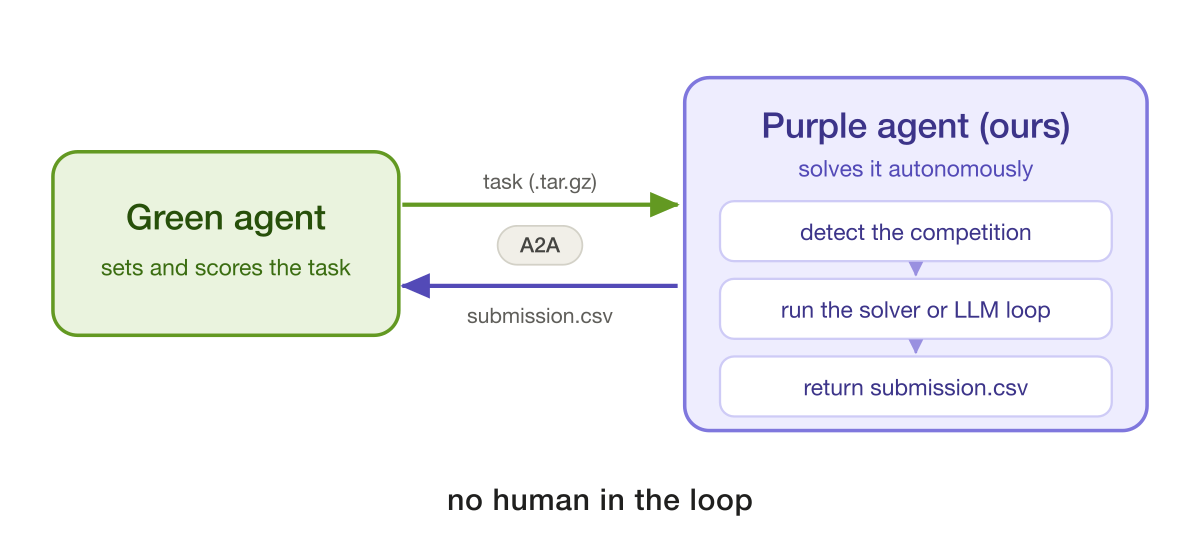
</div>

<div align="center"><em>The competition in one picture:<br/>
a green evaluator agent sets and scores the task; our purple agent solves it on its own over A2A.</em></div>

Our purple agent drew **Spaceship Titanic** and cleared MLE-bench's **gold threshold** — **0.82069**, just past the 0.82066 bar ([documented run](https://github.com/RDI-Foundation/MLE-bench-agentbeats-leaderboard/commit/c181aee126e02548e61e3bbef3bce1f8ea9f49e1)). For scale, 0.82 sits around the **top 6%** of Spaceship Titanic's current public leaderboard: a genuinely strong score, though not the #1 rank. And the part that matters most isn't the number at all — it's that an *autonomous agent* got there end to end and unattended, in a contest where another agent set the task and graded the result.

So this notebook tells both halves: the agent-versus-agent setup that makes MLE-bench genuinely hard, and the exact pipeline the agent produced. The Kaggle solution is the proof; the agentic contest is the point.

**What you'll take away**

- **How an MLE-bench contest actually works** — one agent grades another over A2A, no human at the keyboard, and why that reshapes what a good solver must do.
- **Why a domain rule beats a hyperparameter sweep** — a passenger in cryosleep *can't* spend money, and encoding that recovers more accuracy than any tuning.
- **How to decompose `Cabin` and `PassengerId`** into the deck, side, and group features that carry most of the signal.
- **How to stack three GBDTs without overfitting** on ~8,700 rows, and when a plain weighted average is the safer call.
- **Where cross-validation quietly lies to you** once you add group-level features, and the honest way to report it.

<p style="background-color:#eef6ff;padding:16px;color:#111;font-size:15px;border:2px solid #b6d8ff;border-radius:6px">
<strong>The one idea to take from the solution itself:</strong> on tabular data, <em>domain-driven feature engineering decides the score</em>. The CryoSleep &rarr; spending constraint and the Cabin decomposition move the needle far more than any hyperparameter sweep; the models mostly polish what the features already separate.
</p>


<a id='0'></a>
## How this solution was created: an autonomous agent, not a human

The pipeline below was produced and run by an *autonomous AI agent* competing in the **[AgentX–AgentBeats](https://rdi.berkeley.edu/agentx-agentbeats) competition** organized by **[Berkeley RDI](https://rdi.berkeley.edu/)**. The organizers report 1,300+ teams from 100+ countries and a prize pool above $1M, with the challenge built on top of their Agentic AI MOOC.

### The MLE-bench track

The agent competed on the **MLE-bench** track (based on [OpenAI's MLE-bench](https://arxiv.org/abs/2410.07095)) — a suite of real Kaggle competitions used to test whether an agent can do end-to-end machine learning *with no human in the loop*. The setup pits two agents against each other over Google's [A2A protocol](https://github.com/a2aproject/A2A):

- a **green agent** (the evaluator) sends the competition as a `tar.gz` bundle, data plus task description, and scores whatever comes back;
- a **purple agent** (ours) has to read the data, engineer features, train models, and return a valid `submission.csv` entirely on its own.

### Why this is harder than a normal Kaggle run

In a classic Kaggle notebook *you* are the intelligence: you look at a chart, get an idea, try it. In an agentic competition the loop is closed, and the platform grades the **behavior**, not just the answer. Does the agent call its tools correctly, recover from its own errors, and return a valid submission on every run? A clever pipeline that wins once but crashes one run in five is worthless here.

That reframes the engineering priorities:

| Classic Kaggle | Agentic (MLE-bench) |
|---|---|
| A human iterates by hand | The agent runs end-to-end, unattended |
| One good submission is enough | A valid submission is required on *every* run |
| Peak score is the goal | Reliability **and** peak score are the goal |
| You know the competition | The agent must *detect* it and pick a strategy |

A lesson echoed by [other teams in this competition](https://habr.com/ru/articles/1043574/): wrapping a weak model in elaborate scaffolding tends to produce fragile, hard-to-debug behavior. The platform measures what the agent *actually does*, not how clever its prompt sounds. We saw the same thing first-hand on the LLM side: a mid-tier reasoning model (Gemini 2.5 Pro) drove the agent more reliably than the larger models we tried, which tended to over-think and drift off-plan. So our agent runs a **deterministic solver for competitions it recognizes** (Spaceship Titanic is detected from its column signature, `Transported + Cabin + RoomService`) and only falls back to an LLM loop for the unknown ones. A deterministic solver is run-to-run invariant: given the same data it reproduces the *same* submission every time, so the only thing left to judge is how good that one pipeline is. That pipeline is what the rest of this notebook walks through.

> 🥇 On the live MLE-bench leaderboard the agent's best run scored **0.82069**, a gold medal (threshold 0.82066) — [documented run](https://github.com/RDI-Foundation/MLE-bench-agentbeats-leaderboard/commit/c181aee126e02548e61e3bbef3bce1f8ea9f49e1). During the competition the task was solved by the agent's stochastic LLM loop, and across its eight runs the score ranged from 0.802 to 0.821 — run-to-run variance, not the agent steadily improving: gold landed on the second run and nothing after beat it, and two of the runs are the same Docker image fourteen minutes apart that still disagree. The deterministic solver this notebook walks through was written afterwards to remove exactly that variance — given the same data it reproduces one fixed submission every time. All eight runs are plotted below.

---

In [ ]:
# The agent's eight competition runs (real scores from the MLE-bench-agentbeats
# leaderboard), in the order they happened. Same setup, stochastic LLM loop; the
# deterministic pipeline this notebook walks through removes the run-to-run variance.
import matplotlib.pyplot as plt

runs   = [0.81609, 0.82069, 0.80460, 0.80230, 0.81149, 0.80345, 0.80460, 0.80230]
times  = ["02:19", "02:44", "06:07", "06:25", "07:47", "16:58", "17:27", "17:41"]
labels = [f"#{i+1}\n{t}" for i, t in enumerate(times)]
gold, silver, bronze = 0.82066, 0.81388, 0.80967
gold_line_y = 0.82045  # drawn just below the true bar so the gold column clearly crosses it


def _tier_color(s):
    if s >= gold:   return "#E1A100"
    if s >= silver: return "#9AA0A6"
    if s >= bronze: return "#A0522D"
    return "#4C72B0"


fig, ax = plt.subplots(figsize=(9.6, 5.2))
ax.bar(range(8), runs, color=[_tier_color(s) for s in runs],
       edgecolor="black", linewidth=0.5, zorder=3, width=0.62)
for i, s in enumerate(runs):
    ax.annotate(f"{s:.5f}", (i, s), ha="center", va="bottom", fontsize=8)

for y, name, c in [(gold_line_y, "gold bar 0.82066", "#C98A00"),
                   (silver, "silver 0.81388", "#6B7075"),
                   (bronze, "bronze 0.80967", "#A0522D")]:
    ax.axhline(y, ls="--", lw=1.1, color=c, zorder=2)
    ax.text(7.55, y + 0.00012, name, va="bottom", ha="right", fontsize=8, color=c,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2), zorder=4)

ax.annotate("gold run (0.82069) — and the winning\nsubmission.csv was lost from /tmp, unreproducible",
            xy=(1, 0.82035), xytext=(2.15, 0.8158), ha="left", va="center", fontsize=8.5,
            color="#8a6500", fontweight="bold",
            arrowprops=dict(arrowstyle="->", lw=1.0, color="#8a6500"), zorder=6)
ax.text(6.2, 0.8122, "same Docker image, 14 min apart", ha="center", va="bottom",
        fontsize=8.5, color="#333333", fontweight="bold", zorder=6)
ax.annotate("", xy=(6, 0.8052), xytext=(6.1, 0.8118),
            arrowprops=dict(arrowstyle="->", lw=0.9, color="#333333"), zorder=6)
ax.annotate("", xy=(7, 0.8029), xytext=(6.6, 0.8118),
            arrowprops=dict(arrowstyle="->", lw=0.9, color="#333333"), zorder=6)

# axis-break marks: signal the y-axis is truncated (does not start at 0)
_bk = dict(transform=ax.transAxes, color="black", clip_on=False, lw=1.3, zorder=7)
for _y in (0.018, 0.042):
    ax.plot((-0.013, 0.013), (_y - 0.013, _y + 0.013), **_bk)

ax.set_xticks(range(8)); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0.800, 0.8225); ax.set_xlim(-0.7, 7.7)
ax.set_ylabel("score (accuracy, MLE-bench eval)")
ax.set_title("Eight runs of the agent, same setup: the score crossed three tiers",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", ls=":", alpha=0.4, zorder=0)
fig.text(0.5, -0.02, "Kaggle Spaceship Titanic, 13 Apr UTC, in run order. Tiers are MLE-bench thresholds (not Kaggle medals).",
         ha="center", fontsize=8, style="italic")
fig.text(0.5, -0.06, "Y-axis clipped (0.800-0.822) so the thresholds are visible.",
         ha="center", fontsize=8, style="italic")
plt.tight_layout(); plt.show()


## Table of Contents

- [How this solution was created](#0) — *the agent-vs-agent contest behind it*
1. [Setup & Data Loading](#1)
2. [EDA: what the data is telling us](#2)
   - 2.1 [Overview & Missing Values](#2.1)
   - 2.2 [Target Distribution](#2.2)
   - 2.3 [CryoSleep: The Most Important Feature](#2.3)
   - 2.4 [Cabin Structure: Deck / Num / Side](#2.4)
   - 2.5 [Spending Patterns](#2.5)
   - 2.6 [Age Distribution](#2.6)
   - 2.7 [Group & Family Features](#2.7)
3. [Feature engineering: where the score is won](#3)
4. [Modeling: three GBDTs, and why ten folds](#4)
5. [Ensemble: when stacking earns its place](#5)
6. [Feature importance: what carried the score](#6)
7. [Submission: writing a file that scores](#7)
- [Further reading: notebooks worth your time](#8)

---
<a id='1'></a>
## 1. Setup & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegressionCV
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Record library versions. The pipeline is seed-pinned, so on the same environment it reproduces the
# same submission; the CV itself can still drift a few thousandths across library versions.
import os, sklearn, catboost, lightgbm, xgboost
print(f"numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__} | "
      f"catboost {catboost.__version__} | lightgbm {lightgbm.__version__} | xgboost {xgboost.__version__}")

# Resolve the competition data directory robustly (Kaggle mounts it under /kaggle/input).
import glob
_hits = glob.glob('/kaggle/input/**/train.csv', recursive=True)
if _hits:
    DATA_DIR = os.path.dirname(_hits[0])
    print('Data directory:', DATA_DIR)
else:
    DATA_DIR = '/kaggle/input/spaceship-titanic'
    print('WARNING: train.csv not found under /kaggle/input. Contents:',
          os.listdir('/kaggle/input') if os.path.isdir('/kaggle/input') else '(no /kaggle/input)')

In [ ]:
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')

print(f'Train: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test:  {test.shape[0]} rows, {test.shape[1]} columns')
train.head()

### The columns

The dataset records passengers aboard the *Spaceship Titanic*. Mid-voyage the ship hit a spacetime anomaly and almost half of them were transported into an alternate dimension; our job is to predict which ones.

| Column | Meaning |
|---|---|
| `PassengerId` | `gggg_pp` — a group number and the person's index within that group |
| `HomePlanet` | Planet the passenger departed from |
| `CryoSleep` | Whether the passenger was in suspended animation for the voyage |
| `Cabin` | `deck/num/side`, where side is P (port) or S (starboard) |
| `Destination` | Planet the passenger was travelling to |
| `Age` | Age in years |
| `VIP` | Whether the passenger paid for VIP service |
| `RoomService, FoodCourt, ShoppingMall, Spa, VRDeck` | Amount billed at each of the ship's amenities |
| `Name` | First and last name |
| `Transported` | **Target** — whether the passenger was transported to another dimension |

---
<a id='2'></a>
## 2. EDA: what the data is telling us

<a id='2.1'></a>
### 2.1 Overview & Missing Values

Before building features, we need to understand what we're working with. The key questions:
- Which columns have missing values, and is the missingness random?
- What are the data types — which columns are truly categorical vs numeric?

In [ ]:
# Missing values heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_train = train.isnull().mean().sort_values(ascending=False) * 100
missing_train = missing_train[missing_train > 0]

axes[0].barh(missing_train.index, missing_train.values, color='coral')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values in Train')
for i, v in enumerate(missing_train.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# Data types
dtype_counts = train.dtypes.value_counts()
axes[1].pie(dtype_counts.values, labels=dtype_counts.index.astype(str),
            autopct='%1.0f%%', colors=sns.color_palette('muted'))
axes[1].set_title('Column Data Types')

plt.tight_layout()
plt.show()

print(f'\nTotal missing cells: {train.isnull().sum().sum()} '
      f'({train.isnull().sum().sum() / train.size * 100:.1f}% of all data)')

Most columns have ~2% missing values. This is low enough that simple imputation (median/mode) works fine. But the **pattern** of missingness is itself informative — we'll create binary `_missing` flags later.

<a id='2.2'></a>
### 2.2 Target Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target balance
target_counts = train['Transported'].value_counts()
axes[0].bar(['Not Transported', 'Transported'], target_counts.values,
            color=['#4c72b0', '#dd8452'])
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')

# Transport rate by HomePlanet
transport_by_planet = train.groupby('HomePlanet')['Transported'].mean().sort_values()
axes[1].barh(transport_by_planet.index, transport_by_planet.values, color='#4c72b0')
axes[1].axvline(x=train['Transported'].mean(), color='red', linestyle='--', label='Overall rate')
axes[1].set_xlabel('Transport Rate')
axes[1].set_title('Transport Rate by Home Planet')
axes[1].legend()
for i, v in enumerate(transport_by_planet.values):
    axes[1].text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

The target is almost perfectly balanced (~50/50), so accuracy is a reasonable metric. Europa passengers have a noticeably higher transport rate — planet of origin matters.

<a id='2.3'></a>
### 2.3 CryoSleep: The Most Important Feature

CryoSleep is the single strongest predictor. Passengers in cryosleep are confined to their cabins for the voyage — they **cannot spend money** on any amenities. This domain constraint gives us two powerful imputation rules.

In [ ]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Transport rate by CryoSleep
cryo_rate = train.groupby('CryoSleep')['Transported'].mean()
axes[0].bar(['Awake', 'CryoSleep'], cryo_rate.values, color=['#4c72b0', '#dd8452'])
for i, v in enumerate(cryo_rate.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[0].set_title('Transport Rate by CryoSleep')
axes[0].set_ylabel('Transport Rate')

# Spending by CryoSleep
cryo_spend = train.groupby('CryoSleep')[spend_cols].mean()
cryo_spend.T.plot(kind='bar', ax=axes[1], rot=30)
axes[1].set_title('Avg Spending by CryoSleep')
axes[1].set_ylabel('Amount')
axes[1].legend(['Awake', 'CryoSleep'])

# Verify: CryoSleep=True passengers with non-zero spending
cryo_true = train[train['CryoSleep'] == True]
cryo_has_spend = (cryo_true[spend_cols].fillna(0).sum(axis=1) > 0).sum()
cryo_no_spend = (cryo_true[spend_cols].fillna(0).sum(axis=1) == 0).sum()
axes[2].bar(['Zero spending', 'Has spending'], [cryo_no_spend, cryo_has_spend],
            color=['#55a868', '#c44e52'])
axes[2].set_title(f'CryoSleep=True passengers (n={len(cryo_true)})')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'CryoSleep passengers with non-zero spending: {cryo_has_spend} '
      f'({cryo_has_spend/len(cryo_true)*100:.1f}%)')

**Key findings:**
- CryoSleep passengers are transported at ~80% vs ~30% for awake passengers — a 50pp gap.
- CryoSleep passengers have (nearly) zero spending across every category.

<p style="background-color:#eef6ff;padding:16px;color:#111;font-size:15px;border:2px solid #b6d8ff;border-radius:6px">
<strong>Bidirectional imputation.</strong> Because cryosleep <em>forces</em> zero spending, the two signals fill each other in:
<br>1. <code>CryoSleep = True</code> and a spending value is missing &rarr; set it to <strong>0</strong>.
<br>2. all five spending columns are 0 and <code>CryoSleep</code> is missing &rarr; impute <code>CryoSleep = True</code>.
</p>

These aren't statistical guesses; they follow from the rules of the world. It's an easy edge to give away: fill those spending NaNs with a plain column median and you blur the cleanest signal in the data. We encode the constraint instead, and let it carry a feature.

<a id='2.4'></a>
### 2.4 Cabin Structure: Deck / Num / Side

The `Cabin` column looks like `B/0/P` — it encodes three separate features: **Deck** (letter), **Cabin Number**, and **Side** (Port/Starboard). Let's parse it and see which matter.

In [ ]:
# Parse cabin
train_cabin = train.copy()
train_cabin['Deck'] = train_cabin['Cabin'].apply(
    lambda x: x.split('/')[0] if pd.notna(x) else 'Unknown')
train_cabin['Side'] = train_cabin['Cabin'].apply(
    lambda x: x.split('/')[2] if pd.notna(x) else 'Unknown')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transport rate by Deck
deck_rate = train_cabin.groupby('Deck')['Transported'].agg(['mean', 'count'])
deck_rate = deck_rate.sort_values('mean')
colors = ['#c44e52' if r < 0.5 else '#55a868' for r in deck_rate['mean']]
bars = axes[0].barh(deck_rate.index, deck_rate['mean'], color=colors)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Transport Rate')
axes[0].set_title('Transport Rate by Deck')
for i, (rate, count) in enumerate(zip(deck_rate['mean'], deck_rate['count'])):
    axes[0].text(rate + 0.01, i, f'{rate:.0%} (n={count})', va='center', fontsize=9)

# Transport rate by Side
side_rate = train_cabin.groupby('Side')['Transported'].agg(['mean', 'count'])
axes[1].bar(side_rate.index, side_rate['mean'], color=['#4c72b0', '#dd8452', '#cccccc'])
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Transport Rate')
axes[1].set_title('Transport Rate by Side (P=Port, S=Starboard)')
for i, (rate, count) in enumerate(zip(side_rate['mean'], side_rate['count'])):
    axes[1].text(i, rate + 0.01, f'{rate:.1%}\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Deck is one of the strongest single predictors.** Decks B and C transport roughly 70% of their passengers, well above the 50% base rate, while the other decks sit lower. Deck T looks extreme on the chart but holds only five people, so there is nothing to read into it. Side matters too, and more than you might guess: Starboard (S) passengers are transported about 10 percentage points more often than Port (P). Both Deck and Side are worth pulling out of the raw `Cabin` string.

<a id='2.5'></a>
### 2.5 Spending Patterns

There are five spending categories. Let's see how they relate to transportation and whether log-transforms help.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(spend_cols):
    ax = axes[i // 3][i % 3]
    # Log-transformed distribution by target
    for label, color in [(False, '#4c72b0'), (True, '#dd8452')]:
        vals = np.log1p(train.loc[train['Transported'] == label, col].dropna())
        ax.hist(vals, bins=40, alpha=0.6, color=color,
                label=f'Transport={label}', density=True)
    ax.set_title(col)
    ax.set_xlabel('log(1 + amount)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Total spending
ax = axes[1][2]
train_temp = train.copy()
train_temp['TotalSpend'] = train_temp[spend_cols].sum(axis=1)
for label, color in [(False, '#4c72b0'), (True, '#dd8452')]:
    vals = np.log1p(train_temp.loc[train_temp['Transported'] == label, 'TotalSpend'])
    ax.hist(vals, bins=40, alpha=0.6, color=color,
            label=f'Transport={label}', density=True)
ax.set_title('Total Spending')
ax.set_xlabel('log(1 + amount)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

plt.suptitle('Spending Distributions by Transport Status (log scale)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The spending distributions are heavily right-skewed: a few passengers spend a lot, most spend nothing. **Log-transforms** are essential here. You can also see that transported passengers tend to spend less, since the spike at zero is taller for transported=True.

We'll engineer several spending features:
- `TotalSpend`, `LogTotalSpend`, and a `NoSpend` flag;
- `NumSpendCategories`: how many of the five amenities a passenger used at all, which captures *breadth* of spending separately from the amount;
- per-category ratios (`col / TotalSpend`) that describe a spending *profile*, not just a total;
- `LuxurySpend` (Spa + VRDeck + RoomService) versus `BasicSpend` (FoodCourt + ShoppingMall).

<a id='2.6'></a>
### 2.6 Age Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by target
for label, color in [(False, '#4c72b0'), (True, '#dd8452')]:
    vals = train.loc[train['Transported'] == label, 'Age'].dropna()
    axes[0].hist(vals, bins=40, alpha=0.6, color=color,
                 label=f'Transport={label}', density=True)
axes[0].set_xlabel('Age')
axes[0].set_title('Age Distribution by Transport Status')
axes[0].legend()

# Transport rate by age bin
train_age = train.dropna(subset=['Age']).copy()
train_age['AgeBin'] = pd.cut(train_age['Age'], bins=[0, 12, 18, 25, 35, 50, 80])
age_rate = train_age.groupby('AgeBin', observed=True)['Transported'].agg(['mean', 'count'])
bars = axes[1].bar(range(len(age_rate)), age_rate['mean'],
                   color=['#55a868' if r > 0.5 else '#4c72b0' for r in age_rate['mean']])
axes[1].set_xticks(range(len(age_rate)))
axes[1].set_xticklabels([str(x) for x in age_rate.index], rotation=30)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Transport Rate')
axes[1].set_title('Transport Rate by Age Group')
for i, (rate, count) in enumerate(zip(age_rate['mean'], age_rate['count'])):
    axes[1].text(i, rate + 0.01, f'{rate:.0%}\n(n={count})', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Children (0-12) have a significantly higher transport rate (~67%). This makes sense — children can't use the amenities independently, so they behave more like CryoSleep passengers. We'll create `IsChild` and `IsMinor` flags.

<a id='2.7'></a>
### 2.7 Group & Family Features

The `PassengerId` format is `GGGG_PP` where `GGGG` is a group number and `PP` is person number within the group. Passengers in the same group booked together. Let's check if group members tend to be transported together.

In [ ]:
train_groups = train.copy()
train_groups['GroupId'] = train_groups['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
train_groups['GroupSize'] = train_groups.groupby('GroupId')['GroupId'].transform('count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Group size distribution
gs_counts = train_groups['GroupSize'].value_counts().sort_index()
axes[0].bar(gs_counts.index, gs_counts.values, color='#4c72b0')
axes[0].set_xlabel('Group Size')
axes[0].set_ylabel('Number of Passengers')
axes[0].set_title('Passengers by Group Size')

# Transport rate by group size
gs_rate = train_groups.groupby('GroupSize')['Transported'].mean()
axes[1].bar(gs_rate.index, gs_rate.values,
            color=['#55a868' if r > 0.5 else '#4c72b0' for r in gs_rate.values])
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Group Size')
axes[1].set_ylabel('Transport Rate')
axes[1].set_title('Transport Rate by Group Size')
for i, (x, y) in enumerate(zip(gs_rate.index, gs_rate.values)):
    axes[1].text(x, y + 0.01, f'{y:.0%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# How often are group members transported together?
group_agree = train_groups.groupby('GroupId')['Transported'].agg(
    lambda x: x.nunique() == 1 if len(x) > 1 else np.nan).dropna()
print(f'Groups where ALL members have the same outcome: '
      f'{group_agree.mean():.1%} of {len(group_agree)} multi-person groups')

Most passengers travel solo, but groups of 2-4 exist. Group members are transported together more often than chance — this means **group-level aggregate features** (mean spending, mean age) can leak information about a passenger's outcome through their groupmates.

---
<a id='3'></a>
## 3. Feature engineering: where the score is won

Now we build all features. The strategy:
1. Concatenate train+test for consistent encoding
2. Build features in order: parse --> impute (domain-aware) --> aggregate --> compute --> encode
3. Split back to train/test at the end

All features are computed from the input data only — no target leakage.

In [ ]:
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv')
test_ids = test_raw['PassengerId'].copy()

target = train_raw['Transported'].astype(int)
train_raw = train_raw.drop(columns=['Transported'])

combined = pd.concat([train_raw, test_raw], axis=0, ignore_index=True)
n_train = len(train_raw)
print(f'Combined: {combined.shape}')

In [ ]:
# --- 1. PassengerId -> group features ---
combined['GroupId'] = combined['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
combined['PersonInGroup'] = combined['PassengerId'].apply(lambda x: x.split('_')[1]).astype(int)
combined['GroupSize'] = combined.groupby('GroupId')['PersonInGroup'].transform('count')
combined['IsSolo'] = (combined['GroupSize'] == 1).astype(int)

# --- 2. Cabin -> Deck, CabinNum, Side ---
combined['Deck'] = combined['Cabin'].apply(lambda x: x.split('/')[0] if pd.notna(x) else 'Unknown')
combined['CabinNum'] = combined['Cabin'].apply(lambda x: int(x.split('/')[1]) if pd.notna(x) else -1)
combined['Side'] = combined['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) else 'Unknown')

print('Parsed PassengerId and Cabin')

Two quick decompositions are already paying off. From `PassengerId` we recover the **group** a passenger booked under and its size; from `Cabin` we split out **Deck**, **Side**, and the raw cabin number (`CabinNum`), which roughly tracks position along the ship and carries a little signal of its own.

Next comes the single most useful piece of domain logic in the dataset.

In [ ]:
# --- 3. CryoSleep bidirectional imputation ---
# Rule 1: CryoSleep=True -> spending must be 0
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
cryo_mask = combined['CryoSleep'] == True
for col in spend_cols:
    combined.loc[cryo_mask, col] = combined.loc[cryo_mask, col].fillna(0)

# Rule 2: all spending=0 and CryoSleep unknown -> impute CryoSleep=True
no_spend_mask = (combined[spend_cols].fillna(0).sum(axis=1) == 0) & combined['CryoSleep'].isna()
combined.loc[no_spend_mask, 'CryoSleep'] = True

print(f'Imputed CryoSleep for {no_spend_mask.sum()} passengers with zero spending')

In [ ]:
# --- 4. Spending features ---
combined['TotalSpend'] = combined[spend_cols].sum(axis=1)
combined['LogTotalSpend'] = np.log1p(combined['TotalSpend'])
combined['NoSpend'] = (combined['TotalSpend'] == 0).astype(int)
combined['NumSpendCategories'] = (combined[spend_cols] > 0).sum(axis=1)

for col in spend_cols:
    combined[f'{col}_ratio'] = combined[col] / (combined['TotalSpend'] + 1)
    combined[f'Log{col}'] = np.log1p(combined[col])

combined['LuxurySpend'] = combined['Spa'] + combined['VRDeck'] + combined['RoomService']
combined['BasicSpend'] = combined['FoodCourt'] + combined['ShoppingMall']

print(f'Created {4 + len(spend_cols) * 2 + 2} spending features')

In [ ]:
# --- 5. Age features ---
combined['IsChild'] = (combined['Age'] < 12).astype(int)
combined['IsMinor'] = (combined['Age'] < 18).astype(int)

# --- 6. Name -> Surname -> FamilySize ---
combined['Surname'] = combined['Name'].apply(lambda x: x.split()[-1] if pd.notna(x) else 'Unknown')
combined['FamilySize'] = combined.groupby('Surname')['Surname'].transform('count')

print('Created age and family features')

### Aggregates: borrowing signal from neighbours

Passengers do not travel in isolation, so the next features summarise each passenger's **group** and **deck**:
- `Group_TotalSpend_mean` and `Group_Age_mean` — the booking group's average spend and age, since groupmates share an outcome more often than chance (§2.7);
- `Deck_TotalSpend_mean` — the average spend on a passenger's deck, a proxy for that deck's wealth level that still helps when the deck is known but a passenger's own spend is missing.

In [ ]:
# --- 7. Group-level aggregates ---
combined['Group_TotalSpend_mean'] = combined.groupby('GroupId')['TotalSpend'].transform('mean')
combined['Group_Age_mean'] = combined.groupby('GroupId')['Age'].transform('mean')

# --- 8. Deck-level aggregates ---
combined['Deck_TotalSpend_mean'] = combined.groupby('Deck')['TotalSpend'].transform('mean')

print('Created group and deck aggregates')

In [ ]:
# --- 9. Missing indicators (before imputation) ---
missing_flag_cols = ['Age', 'CryoSleep', 'VIP', 'RoomService', 'FoodCourt',
                     'ShoppingMall', 'Spa', 'VRDeck', 'Cabin', 'HomePlanet', 'Destination']
for col in missing_flag_cols:
    if col in combined.columns and combined[col].isnull().any():
        combined[f'{col}_missing'] = combined[col].isnull().astype(int)

# --- 10. Imputation ---
for col in combined.select_dtypes(include=[np.number]).columns:
    combined[col] = combined[col].fillna(combined[col].median())

for col in combined.select_dtypes(include=['object', 'bool']).columns:
    if col not in ['PassengerId', 'Name', 'Cabin', 'Surname']:
        mode_val = combined[col].mode()
        combined[col] = combined[col].fillna(mode_val[0] if len(mode_val) > 0 else 'Unknown')

# --- 11. Drop raw columns ---
combined = combined.drop(columns=['PassengerId', 'Name', 'Cabin', 'Surname'])

# --- 12. Label encode ---
for col in combined.select_dtypes(include=['object', 'bool', 'category']).columns:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))

print(f'Final feature set: {combined.shape[1]} columns')
print(f'Missing values remaining: {combined.isnull().sum().sum()}')

In [ ]:
# Split back to train / test
X_train = combined.iloc[:n_train].values
X_test = combined.iloc[n_train:].values
y_train = target.values
feature_names = list(combined.columns)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

We started with 13 raw columns and finished with **50 engineered features**, none of them missing a value. The ones that usually carry the most weight are the CryoSleep flag, the spending aggregates, and Deck, but we will let the models confirm that in §6 rather than taking it on faith.

---
<a id='4'></a>
## 4. Modeling: three GBDTs, and why ten folds not five

The metric is plain **accuracy**, and because the classes are almost perfectly balanced (§2.2) we can threshold the predicted probabilities at **0.5** without tuning a decision boundary.

We train three gradient-boosting models (CatBoost, LightGBM, XGBoost), each with **10-fold StratifiedKFold** and early stopping on the held-out fold. Stratification preserves the 50/50 class split in every fold, and ten folds trade a little compute for lower-variance estimates on ~8,700 rows. CatBoost and XGBoost stop after 100 stale rounds; LightGBM gets a slightly longer leash at 200.

For each model we keep two things:
- **out-of-fold (OOF) predictions** on train — every row scored by a model that never saw it, so these estimates do not flatter us;
- **test predictions** averaged across all ten folds.

The OOF predictions become the meta-features for the stacking ensemble in §5.

> **An honest caveat about leakage.** Several features are group- and deck-level *aggregates* (§3), and we compute them once on the full frame *before* cross-validation. So when a row lands in a validation fold, its `Group_*`/`Deck_*` means were built partly from its own groupmates, and a little information seeps from validation into training. That makes the OOF accuracy a touch optimistic. The usual reflex is to blame the fold scheme (`StratifiedKFold` vs `GroupKFold`), but that is the smaller half: swapping in `GroupKFold` barely moves the number, because the leak rides in through *where* the aggregates are computed, not which rows share a fold. The clean fix is to recompute the group/deck means inside each fold. In practice the gap here is small, within the fold-to-fold spread, so we keep the simpler pipeline and flag it honestly rather than chase a fraction of a point.

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models_config = {
    'CatBoost': lambda: CatBoostClassifier(
        iterations=2000, learning_rate=0.05, depth=6,
        l2_leaf_reg=5, random_seed=42, early_stopping_rounds=100, verbose=0),
    'LightGBM': lambda: LGBMClassifier(
        n_estimators=2000, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, reg_alpha=0.3, reg_lambda=0.3,
        colsample_bytree=0.7, subsample=0.7, subsample_freq=5,
        random_state=42, n_jobs=-1, verbose=-1),
    'XGBoost': lambda: XGBClassifier(
        n_estimators=2000, learning_rate=0.05, max_depth=6,
        min_child_weight=5, reg_alpha=0.3, reg_lambda=1.5,
        colsample_bytree=0.7, subsample=0.7,
        random_state=42, n_jobs=-1, verbosity=0,
        eval_metric='logloss', early_stopping_rounds=100),
}

In [ ]:
oof_preds = {}
test_preds = {}
cv_scores = {}

for model_name, model_factory in models_config.items():
    print(f'\n--- {model_name} ---')
    oof = np.zeros(len(X_train), dtype=np.float64)
    test_fold_preds = np.zeros(len(X_test), dtype=np.float64)

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = model_factory()

        if model_name == 'CatBoost':
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        elif model_name == 'XGBoost':
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        elif model_name == 'LightGBM':
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(200, verbose=False),
                                 lgb.log_evaluation(0)])

        oof[val_idx] = model.predict_proba(X_val)[:, 1]
        test_fold_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

        if (fold_idx + 1) % 5 == 0:
            fold_acc = accuracy_score(y_val, (oof[val_idx] > 0.5).astype(int))
            print(f'  Fold {fold_idx+1}/10  val_acc={fold_acc:.5f}')

    cv_acc = accuracy_score(y_train, (oof > 0.5).astype(int))
    cv_scores[model_name] = cv_acc
    oof_preds[model_name] = oof
    test_preds[model_name] = test_fold_preds
    print(f'  CV accuracy: {cv_acc:.5f}')

print('\n=== Summary ===')
for name, score in sorted(cv_scores.items(), key=lambda x: -x[1]):
    print(f'  {name}: {score:.5f}')

All three models land within about a quarter of a percentage point of each other (0.810 to 0.813). That is the sweet spot for stacking: similar accuracy, but errors that do not line up perfectly. A model that lagged far behind would only drag the blend down; three close, partly-uncorrelated models should combine into something a little better than any one of them alone.

---
<a id='5'></a>
## 5. Ensemble: when stacking earns its place

We compare two ensemble strategies and pick the better one:

1. **Weighted average** — weight each model's predictions proportionally to its CV accuracy
2. **Stacking** — use OOF predictions as features for a LogisticRegressionCV meta-learner

Stacking is more flexible (it can learn non-equal weights and correct for correlated errors), but on small data it risks overfitting.

In [ ]:
model_names = list(cv_scores.keys())

# --- Method 1: Weighted average ---
weights = np.array([cv_scores[m] for m in model_names])
weights = weights / weights.sum()

weighted_oof = np.zeros(len(X_train), dtype=np.float64)
weighted_test = np.zeros(len(X_test), dtype=np.float64)
for i, m in enumerate(model_names):
    weighted_oof += oof_preds[m] * weights[i]
    weighted_test += test_preds[m] * weights[i]

weighted_cv = accuracy_score(y_train, (weighted_oof > 0.5).astype(int))
print(f'Weighted average CV: {weighted_cv:.5f}')
print(f'  Weights: {dict(zip(model_names, [f"{w:.3f}" for w in weights]))}')

# --- Method 2: Stacking ---
oof_stack = np.column_stack([oof_preds[m] for m in model_names])
test_stack = np.column_stack([test_preds[m] for m in model_names])

meta = LogisticRegressionCV(cv=5, random_state=42, max_iter=1000)
meta.fit(oof_stack, y_train)
meta_oof = meta.predict_proba(oof_stack)[:, 1]
meta_cv = accuracy_score(y_train, (meta_oof > 0.5).astype(int))
print(f'\nStacking CV:         {meta_cv:.5f}')
print(f'  Meta-learner coefs: {dict(zip(model_names, [f"{c:.3f}" for c in meta.coef_[0]]))}')

# --- Pick the winner ---
if meta_cv >= weighted_cv:
    final_proba = meta.predict_proba(test_stack)[:, 1]
    print(f'\n>>> Using STACKING (CV={meta_cv:.5f})')
else:
    final_proba = weighted_test
    print(f'\n>>> Using WEIGHTED AVERAGE (CV={weighted_cv:.5f})')

In [ ]:
# Visualize: OOF correlation between models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Correlation heatmap
oof_df = pd.DataFrame(oof_stack, columns=model_names)
corr = oof_df.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
            vmin=0.8, vmax=1.0, square=True)
axes[0].set_title('OOF Prediction Correlation')

# CV scores comparison
all_scores = {**cv_scores, 'Weighted': weighted_cv, 'Stacking': meta_cv}
colors = ['#4c72b0'] * len(cv_scores) + ['#dd8452', '#55a868']
bars = axes[1].bar(all_scores.keys(), all_scores.values(), color=colors)
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('Individual vs Ensemble CV Accuracy')
axes[1].set_ylim(min(all_scores.values()) - 0.005, max(all_scores.values()) + 0.005)
for bar, score in zip(bars, all_scores.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, score + 0.0005,
                 f'{score:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

The ensemble improves on every individual model — even a small gain of 0.1-0.3pp matters at the top of the leaderboard. The models are correlated (they see the same features), but each has slightly different inductive biases, which is why ensembling helps.

---
<a id='6'></a>
## 6. Feature importance: what actually carried the score

Let's see which features the models rely on the most. We'll use the last fold's LightGBM model since it exposes `feature_importances_` directly.

In [ ]:
# Retrain a single LightGBM for feature importance
lgb_model = LGBMClassifier(
    n_estimators=2000, learning_rate=0.05, num_leaves=31,
    min_child_samples=20, reg_alpha=0.3, reg_lambda=0.3,
    colsample_bytree=0.7, subsample=0.7, subsample_freq=5,
    random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)

importance = pd.Series(lgb_model.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=True)

# Top 25 features
fig, ax = plt.subplots(figsize=(10, 8))
importance.tail(25).plot(kind='barh', ax=ax, color='#4c72b0')
ax.set_xlabel('Feature Importance (split count)')
ax.set_title('Top 25 Features (LightGBM)')
plt.tight_layout()
plt.show()

---
<a id='7'></a>
## 7. Submission: writing a file that scores

In [ ]:
predictions = (final_proba > 0.5)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': predictions,
})
submission['Transported'] = submission['Transported'].map({True: 'True', False: 'False'})
submission.to_csv('submission.csv', index=False)

# Validate against sample
sample = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')
assert len(submission) == len(sample), f'Row mismatch: {len(submission)} vs {len(sample)}'
assert list(submission.columns) == list(sample.columns), 'Column mismatch'

print(f'Final CV accuracy: {max(weighted_cv, meta_cv):.5f}')
print(f'Submission saved: {len(submission)} rows')
print(f'Predicted transport rate: {predictions.mean():.1%}')
submission.head(10)

---

## Results

Here are the 10-fold CV accuracies from this run (seeded, so they reproduce; they move only a few thousandths with library versions):

| Model | 10-fold CV accuracy |
|---|---|
| CatBoost | 0.8128 |
| XGBoost | 0.8110 |
| LightGBM | 0.8103 |
| Weighted average | 0.8127 |
| **Stacking (selected)** | **0.8138** |

The three base models sit within a quarter of a percentage point of each other, and stacking edges past the best of them. Small, but on a balanced-accuracy task that margin is the whole game.

A word on the headline number. This gold is real, and it's the **agent competition's**: our agent cleared MLE-bench's gold bar with **0.82069** (threshold **0.82066**), [verifiable here](https://github.com/RDI-Foundation/MLE-bench-agentbeats-leaderboard/commit/c181aee126e02548e61e3bbef3bce1f8ea9f49e1). One thing to keep straight — Spaceship Titanic is a Kaggle *Getting Started* competition, which awards no Kaggle medals at all, so there is no "Kaggle gold" to compare against; the medal here is the one the agent earned in the contest. The **top 6%** is only a yardstick for the score (0.82 is genuinely strong; the open board's very top usually comes from overfitting the small public split). What stands out: an autonomous agent reached it end to end, judged by another agent.

To be precise about what *this* notebook reproduces: the deterministic pipeline here scores about **0.81 on cross-validation**, and it is a faithful reimplementation, not the exact stochastic run that hit 0.82069 (that `submission.csv` is the one lost from `/tmp`). Expect a fork to land near its CV on the public board, not the 0.82069 headline. And on a Getting Started task with thousands of public solutions, a real share of any strong score (the agent's included) is faithful recall and reliable execution of well-known techniques, not novel reasoning. The story here is the autonomy and the reliability, not a new modelling trick.

Two lessons that carry over to most tabular problems:
1. **Domain logic beats tuning.** The CryoSleep and spending constraint, and the Cabin decomposition, moved the score far more than any hyperparameter search.
2. **Ensembling is insurance, not magic.** Three correlated GBDTs blended through a logistic meta-learner buy a small, dependable gain. They will not rescue weak features.

Three things the *agent* contest itself taught me:
1. **Reliability beats cleverness.** A pipeline that wins once but errors one run in five is worthless when the grader runs you unattended; the deterministic solver exists for exactly that.
2. **One run is a noisy verdict.** The same agent scored 0.802 to 0.821 on this task (chart up top). A single number is a sample, not a skill level, so you want a spread before you trust a delta.
3. **An artifact you can't reproduce is one you can't trust.** The gold-scoring `submission.csv` was lost from `/tmp`; this seed-pinned rebuild is the auditable version that loss made necessary.

The whole pipeline runs in a few minutes on a Kaggle CPU instance, and every step is seeded (`random_state=42`), so a re-run reproduces the same submission.

## Design choices and limitations

A few decisions shaped the score as much as the features did, so they are worth stating plainly:

- **Only three models.** The agent's LLM fallback can also call on ExtraTrees and RandomForest, but this solver keeps the three gradient-boosting models that were individually strongest. Extra base models mostly added correlated noise and overfitting risk to the stack.
- **Stacking only when it earns its place.** The meta-learner is used for the final submission only if it beats the plain weighted average on CV; otherwise we fall back to the simpler, harder-to-overfit blend.
- **Group aggregates, kept modest.** Group and deck means help, but piling on more group-level statistics inflates the CV (through the leakage noted in §4) without moving the leaderboard. We stopped at means.
- **No target encoding.** Tempting for `HomePlanet`, `Destination`, and `Deck`, but it has to be fit inside each fold to stay honest, and label encoding plus the aggregates already captured most of that signal.

The highest-leverage next steps, if you want to push past this: interaction features such as `Deck × CryoSleep`, in-fold target encoding done carefully, and a proper `GroupKFold` so the cross-validation stops being slightly optimistic.

---

## Summary

| Step | What we did | Why it matters |
|------|------------|----------------|
| CryoSleep imputation | Bidirectional domain logic | Recovers missing labels using game rules, not statistics |
| Cabin parsing | Deck / Num / Side | Deck is among the strongest single splits |
| Spending features | Log-transforms, ratios, luxury vs basic | Reduces skewness, captures spending profile |
| Group aggregates | Mean spending and age per booking group | Group members share outcomes |
| Missing indicators | Binary flags before imputation | Missingness pattern is predictive |
| 3-model ensemble | CatBoost + LightGBM + XGBoost | Different inductive biases; stacking finds the best blend |

The pattern to take away: domain-driven feature engineering decides the score, and the ensemble merely polishes it. The trade-offs behind these choices, and the highest-leverage next steps, are in the two sections above.

<a id='8'></a>
## Further reading: notebooks worth your time

Credit where it's due. Spaceship Titanic has a deep bench of public work, and many ideas here — parsing `Cabin`, exploiting the CryoSleep–spending link, building group features — are community knowledge refined over years of public notebooks. These are the ones I'd point a friend to, grouped by what you might want next.

**Start here (complete walkthroughs)**
- [🚀 Spaceship Titanic: A complete guide](https://www.kaggle.com/code/samuelcortinhas/spaceship-titanic-a-complete-guide) by Samuel Cortinhas — the canonical end-to-end tutorial: EDA, missing values, preprocessing, model selection. The best first stop.
- [Spaceship Titanic: ~81% easy to understand](https://www.kaggle.com/code/raulparis/spaceship-titanic-81-easy-to-understand) by raulparis — a clean, beginner-friendly path that still reaches ~0.81.

**Go deeper on EDA and feature engineering**
- [Spaceship Titanic: EDA + Machine Learning (0.81)](https://www.kaggle.com/code/mateuszk013/spaceship-titanic-eda-machine-learning) by mateuszk013 — polished, visual EDA wired into a clean modeling pipeline.
- [Feature Engineering + Baseline](https://www.kaggle.com/code/defcodeking/spaceship-titanic-feature-engineering-baseline) by defcodeking — a focused deep dive on the part that moves the score most.

**Compare models and approaches**
- [EDA + 27 different models](https://www.kaggle.com/code/odins0n/spaceship-titanic-eda-27-different-models) by odins0n — a breadth-first benchmark of 27 classifiers; great for intuition about which families fit this data.
- [AutoGluon Spaceship Titanic](https://www.kaggle.com/code/cozyhn/autogluon-spaceship-titanic) by cozyhn — the AutoML counterpoint to our hand-built stack, and a useful baseline to measure manual work against.

**Aim for the top of the leaderboard**
- [Among the Elite 🛸 Top 100](https://www.kaggle.com/code/tronrover/among-the-elite-top-100-spaceship-titanic) by tronrover — a leaderboard-focused push aimed at the very top.
- [Top 10% (0.80617)](https://www.kaggle.com/code/doggypiggy/spaceship-titanic-top-10-0-80617) by doggypiggy — a compact, reproducible recipe for a strong rank.

Comparing a few side by side is the fastest way to see which ideas are fundamental: the same moves recur, and each author adds an angle.

### Credits

Thanks to the Spaceship Titanic organizers for a genuinely well-designed starter competition, and to the Kaggle community whose public notebooks established the feature set this solution stands on. The CryoSleep–spending rule and the Cabin decomposition are community discoveries rather than ours; Samuel Cortinhas's [complete guide](https://www.kaggle.com/code/samuelcortinhas/spaceship-titanic-a-complete-guide) is a good single reference for where they come from.

### On the agentic side

Curious about the competition this solution actually ran in, and why a mid-tier model can beat a bigger one there? The field report [«Агент против агента: опыт участия в BitGN PAC1 и AgentBeats»](https://habr.com/ru/articles/1043574/) (in Russian) goes deeper than the backstory at the top of this notebook.

---

If this walkthrough helped, an upvote makes it easier for the next person to find. And if you run the pipeline, tell me in the comments which feature gave *you* the biggest jump — for us it was the CryoSleep imputation, with the deck features a close second.

*Written by [Georgy Mamarin](https://www.kaggle.com/georgymamarin). The agent, the solver, and this write-up are part of a gold-medal MLE-bench entry in the Berkeley AgentX–AgentBeats competition — full agent code and the gold-run provenance live in the [GitHub repo](https://github.com/dmagog/mle-purple-agent).*